In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
from math import sqrt
import time
import re
from scipy import signal
import ipywidgets as widgets
from src.analisi.tools import *

In [2]:
%matplotlib widget
plt.close('all')

In [3]:
# selettore cartella
folder_selector = widgets.Dropdown( 
    options=sorted([f for f in os.listdir(base_img_folder) if os.path.isdir(os.path.join(base_img_folder, f))], reverse=True),
    description='Sessione:',
    style={'description_width': 'initial'}
)

display(folder_selector)

Dropdown(description='Sessione:', options=('percolazione', 'lampadina_test_final', 'lampadina3_test', 'lampadi…

In [4]:
#raccolgiamo le immagini per calcolare le intensità medie 

images, image_timestamps = load_images_from_folder(os.path.join(base_img_folder, folder_selector.value, 'images'))
images, image_timestamps = sort_images_and_timestamps(images, image_timestamps)

image_seconds = [time.mktime(time.strptime(ts, FORMATO_COMUNE)) for ts in image_timestamps]
image_seconds = np.array(image_seconds)

image_trel = image_seconds - image_seconds[0]

In [5]:
print(image_seconds.shape)

(1076,)


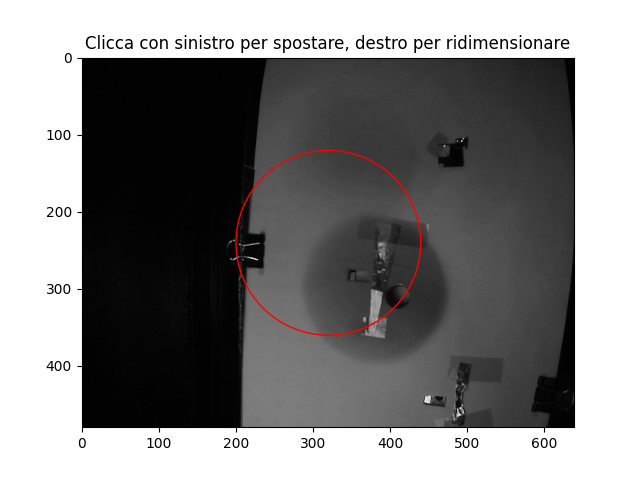

In [6]:
roi_select = RoiSelectorWidget(images[-1])

In [7]:
roi_center, roi_radius = roi_select.roi

In [8]:
def build_roi(im0, center_x, center_y, radius):
    
    h, w = im0.shape[:2]
    Y, X = np.ogrid[:h, :w]
    
    dist_from_center = np.sqrt((X - center_x)**2 + (Y - center_y)**2)
    
    mask = dist_from_center <= radius
    
    return mask

In [9]:
def extract_roi_from_images(images, mask):
    return [image * mask for image in images]

In [10]:
def compute_mean(images, roi_mask):
    return [np.mean(image[roi_mask > 0]) for image in images]

In [11]:
def compute_diff_imgs(images, reference_image):
    return [reference_image - image for image in images]

In [12]:
reference_image = np.mean(images[:10], axis=0) if images else None
roi_mask = build_roi(reference_image, roi_center[0], roi_center[1], roi_radius)
roi_images = extract_roi_from_images(images, roi_mask)
reference_image_roi = extract_roi_from_images([reference_image], roi_mask)[0]
difference_images = compute_diff_imgs(roi_images, reference_image_roi)
mean_intensities = np.array(compute_mean(difference_images, roi_mask))

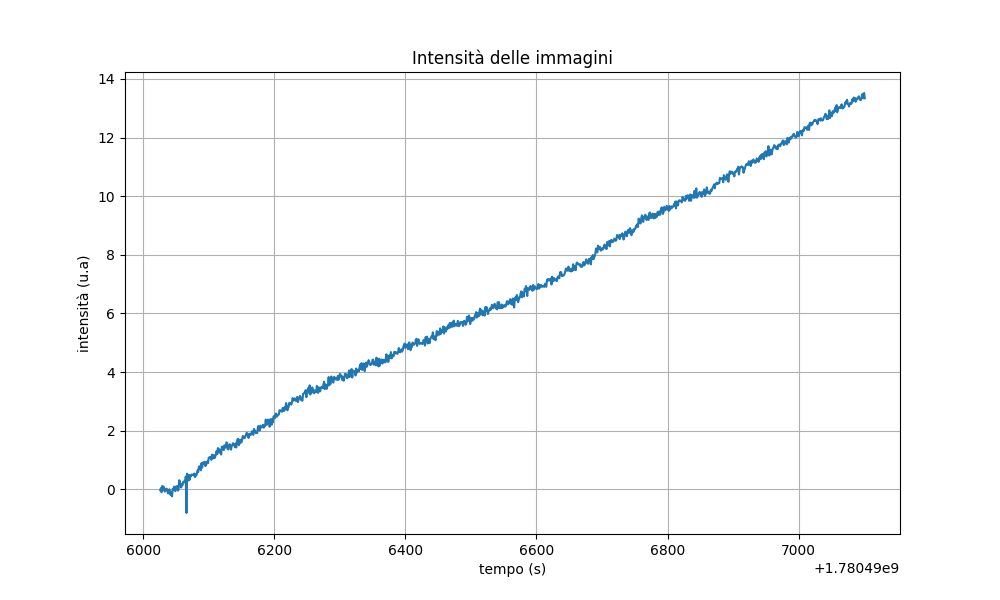

In [40]:
plt.figure(figsize=(10,6))

plt.plot(image_seconds, mean_intensities)
plt.title("Intensità delle immagini")
plt.xlabel("tempo (s)")
plt.ylabel("intensità (u.a)")
plt.grid()
plt.show()

In [ ]:
#window_size = 10

#images_smooth = moving_average_images(difference_images, window_size)
#mean_intensities = np.mean(images_smooth, axis=(1, 2))

In [14]:
print(mean_intensities[-1] - mean_intensities[0])

13.379037574159524


In [15]:
bilancia_timestamps, bilancia_thicknesses, bilancia_rates = load_bilancia_data(os.path.join(base_img_folder, folder_selector.value, "data", 'points.txt'))
bilancia_timestamps = np.array(bilancia_timestamps)
bilancia_trel = bilancia_timestamps - bilancia_timestamps[0]

In [16]:
print(image_seconds[0])
print(image_seconds.shape)
print(bilancia_timestamps[0])
print(bilancia_timestamps.shape)
print(bilancia_trel[0])
print(bilancia_trel.shape)


1780496026.0
(1076,)
1780496033.8412511
(4255,)
0.0
(4255,)


In [18]:
print(bilancia_timestamps[-1])
print(image_seconds[-1])

1780496219.9603376
1780497101.0


In [19]:
t0 = bilancia_timestamps[0]
tf = bilancia_timestamps[-1]


time_mask = (image_seconds >= t0) & (image_seconds <= tf)
image_seconds_masked = image_seconds[time_mask]
mean_intensities_masked = mean_intensities[time_mask]

In [20]:
bilancia_trel = bilancia_timestamps - t0
image_trel = image_seconds_masked - t0

In [21]:
print(bilancia_trel.shape)
print(image_trel.shape)

(4255,)
(186,)


In [ ]:
# dati di intensità della camera limitati al tempo di misura della bilancia
interpolated_thicknesses = np.interp(bilancia_trel, image_trel, mean_intensities_masked) 

/tmp/ipykernel_816/1885247310.py:1: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(10, 6))


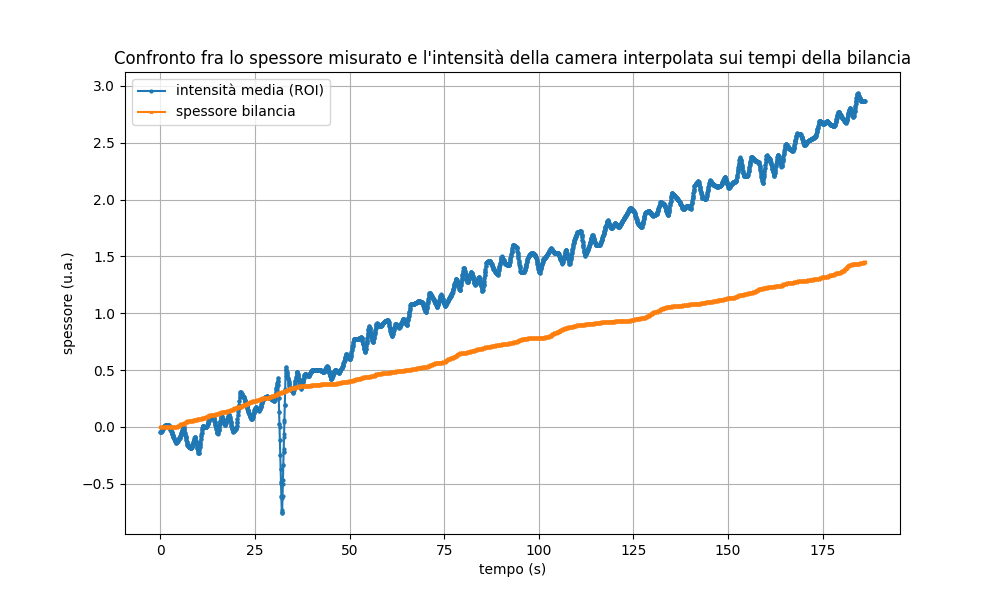

In [43]:
plt.figure(figsize=(10, 6))

plt.plot(bilancia_trel, interpolated_thicknesses, label='intensità media (ROI)', marker='o', markersize="2")
plt.plot(bilancia_trel, bilancia_thicknesses, label='spessore bilancia', marker='x', markersize="2")
plt.title("Confronto fra lo spessore misurato e l'intensità della camera interpolata sui tempi della bilancia")
plt.xlabel("tempo (s)")
plt.ylabel("spessore (u.a.)")
plt.legend()
plt.grid()
plt.show()

In [ ]:
# m e q forniscono i fattori di scala fra i dati raccolti dalla bilancia e quelli raccolti dalla camera
m, q = np.polyfit(interpolated_thicknesses, bilancia_thicknesses, 1)
print(f"Coefficiente angolare: {m}, intercetta: {q}")

Coefficiente angolare: 0.4626651979968327, intercetta: 0.11019525554997496


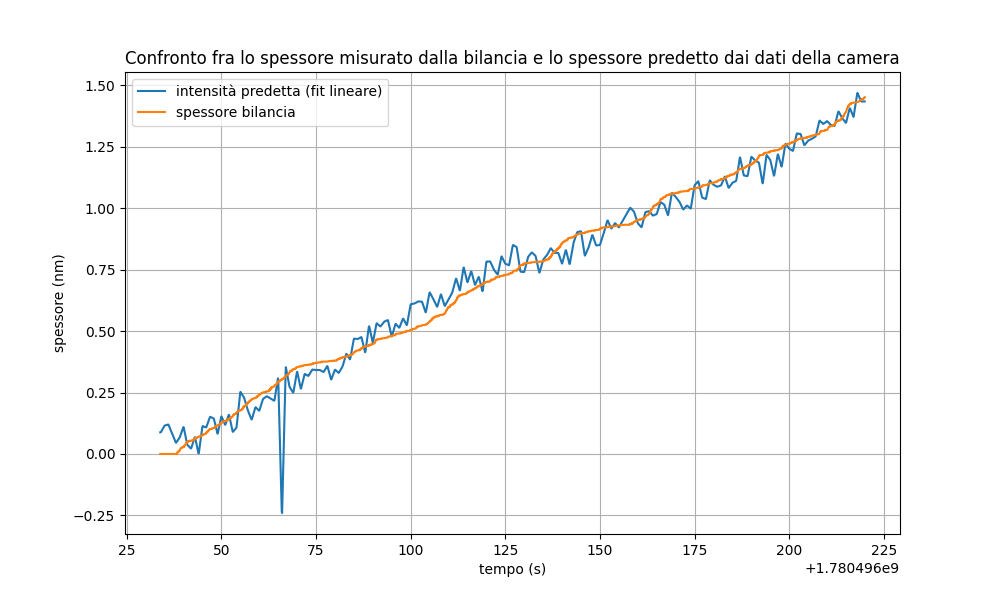

In [42]:
plt.figure(figsize=(10, 6))

predicted_thicknesses = m * interpolated_thicknesses + q # questo è il dato di intensità "convertito" in spessore 

plt.plot(bilancia_timestamps, predicted_thicknesses, label='intensità predetta (fit lineare)')

plt.plot(bilancia_timestamps, bilancia_thicknesses, label='spessore bilancia')

plt.xlabel('tempo (s)')
plt.ylabel('spessore (nm)') #era segnato lo spessore in mm, ho corretto in nm, era una svista?
plt.title("Confronto fra lo spessore misurato dalla bilancia e lo spessore predetto dai dati della camera")
plt.grid()
plt.legend()
plt.show()

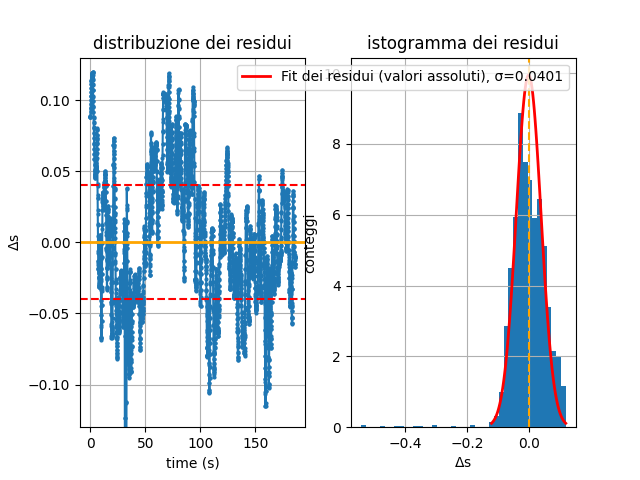

In [103]:
residui = predicted_thicknesses - bilancia_thicknesses



predicted_thicknesses_std = np.std(abs(residui))  # deviazione standard dei residui del fit lineare
media_residui = np.mean(residui)

Nbins = N = round(len(residui)/100)

fig, (ax1,ax2) = plt.subplots(1,2)

ax1.plot(bilancia_trel, residui, marker='o', markersize='2')
ax1.set_title("distribuzione dei residui")
ax1.set_ylabel("$\Delta$s")
ax1.set_ylim(bottom=-0.13, top=0.13) #RICORDARSI DI COMMENTARE LA "CADUTA" DEI DATI INTORNO A 30 S SE RIUSCIAMO A SPIEGARLA
ax1.set_xlabel("time (s)")
ax1.axhline(media_residui, color="orange", linestyle="-", label=f'Media dei residui', linewidth=2)
ax1.axhline(predicted_thicknesses_std, color="r", linestyle="--", label=f'Deviazione standard dei residui: {predicted_thicknesses_std:.4f}')
ax1.axhline(-predicted_thicknesses_std, color="r", linestyle='--')
ax1.grid()


ax2.hist(residui, Nbins, density=True)
ax2.set_ylabel("conteggi")
ax2.set_xlabel("$\Delta$s")
ax2.set_title("istogramma dei residui")
ax2.grid()

xs = np.linspace(-3*predicted_thicknesses_std, 3*predicted_thicknesses_std, 100)
ys = (1 / (predicted_thicknesses_std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((xs) / predicted_thicknesses_std) ** 2)
ax2.plot(xs, ys, color='r', label=f'Fit dei residui (valori assoluti), σ={predicted_thicknesses_std:.4f}', linewidth=2 )
ax2.axvline(media_residui, color="orange", linestyle="--")

plt.legend()
plt.show()

In [33]:
print("time passed", bilancia_timestamps[-1] - bilancia_timestamps[0])
print("bilancia_thicknesses", bilancia_thicknesses[-1] - bilancia_thicknesses[0])
print("average rate", (bilancia_thicknesses[-1] - bilancia_thicknesses[0]) / (bilancia_timestamps[-1] - bilancia_timestamps[0]))

time passed 186.11908650398254
bilancia_thicknesses 1.452
average rate 0.00780145673006476


In [ ]:
avg_rate = (4.5- 0) / (17*60)
avg_rate_min = avg_rate * 60

print(f"Average deposition rate: {avg_rate:.4f} nm/s")
print(f"Average deposition rate: {avg_rate_min:.4f} nm/min")

In [ ]:
all_thicknesses = m * mean_intensities + q # questi sono gli spessori

plt.figure(figsize=(10, 6))

plt.plot(all_thicknesses, label='Predicted Thickness (All Data)', color='purple')
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))

rates = np.gradient(bilancia_thicknesses, bilancia_timestamps)

plt.plot(rates, label='Bilancia Rates', color='red')

mean_rate = np.mean(rates[rates >= 0])  # Consider only positive rates for mean calculation
plt.axhline(mean_rate, color='blue', linestyle='--', label=f'Mean Rate: {mean_rate:.2f} mm/s')
print("mean_rate", mean_rate)  # Convert to mm/s


plt.show()